# Direct and total downwelling irradiance

This tutorial computes the solar irradiance reaching the sea surface for a given atmosphere (aerosol
optical thickness, water vapour, ozone): the **direct** irradiance of the solar beam, the **total**
(direct + diffuse) downwelling irradiance and, by difference, the **diffuse** irradiance of the sky.

All the terms are computed at the full spectral resolution of the gaseous absorption look-up table
(350--2500 nm), from the equations of the {doc}`../methods` page:

- plane solar irradiance at the top of the atmosphere (Eq. {eq}`e0`):

$$
E_0(\lambda) = \mu_0\, d^2(J)\, F_0(\lambda),
$$

- direct irradiance at the surface, attenuated along the solar path by the scattering and absorption
  of the molecules and aerosols and by the gaseous absorption (Beer-Lambert law, Eq. {eq}`tdir` with
  the air mass of the solar path $1/\mu_0$):

$$
E_{dir}(\lambda) = E_0(\lambda)\; T_g^{\downarrow}(\lambda)\;
\exp\left[ -\frac{\tau_r(\lambda) + \tau_a(\lambda)}{\mu_0} \right],
$$

- total downwelling irradiance at the surface (Eq. {eq}`ed`), with $T^{\downarrow}$ the total
  (direct + diffuse) irradiance transmittance of the Rayleigh-aerosol atmosphere computed by radiative
  transfer:

$$
E_d(\lambda) = E_0(\lambda)\; T_g^{\downarrow}(\lambda)\; T^{\downarrow}(\lambda, \theta_s, \tau_a),
$$

- diffuse irradiance of the sky:

$$
E_{diff}(\lambda) = E_d(\lambda) - E_{dir}(\lambda).
$$

The same gaseous transmittance (computed for the direct solar path) is applied to the direct and
diffuse components.

In [1]:
import logging

import matplotlib.pyplot as plt
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})
# no warning when the Times New Roman font is not installed
logging.getLogger('matplotlib.font_manager').setLevel(logging.ERROR)

import numpy as np
import xarray as xr

import radcalnet_oc as radoc
# radcalnet_oc sets the root logger to INFO: show only the warnings in this tutorial
logging.getLogger().setLevel(logging.WARNING)
print(f'radcalnet_oc: {radoc.__version__}')

radcalnet_oc: 0.0.3


## Atmosphere and geometry

The gas columns are given in kg m$^{-2}$: the precipitable water in cm is multiplied by 10 and the
ozone column in Dobson units by $2.14485\cdot10^{-5}$.

The aerosols are described by the proportions of the aerosol models of `config.yml` (continental
average and maritime clean here, see {ref}`methods-aerosol`) and by their optical thickness at 550 nm.

In [2]:
# geometry and date
sza = 40.            # solar zenith angle (deg)
day_of_year = 172    # 21 June

# atmosphere
pressure = 1013.25   # surface pressure (hPa)
aot550 = 0.1         # aerosol optical thickness at 550 nm
tpw_cm = 2.0         # precipitable water (cm)
to3_du = 300.        # total ozone (DU)
tcno2 = 3e-6         # nitrogen dioxide column (kg m-2)

# proportion of each aerosol model of config.yml
print(radoc.lut.AEROSOL_MODELS)
aerosol_combination = [0, 0.5, 0, 0.5, 0, 0]   # 50 % continental average, 50 % maritime clean

# unit conversions into kg m-2
tcwv = tpw_cm * 10
tco3 = to3_du * 2.14485e-5

['ARCT_rh70', 'COAV_rh70', 'DESE_rh70', 'MACL_rh70', 'URBA_rh70', 'WASO_rh0']


## Look-up tables

{py:meth}`LUT.lut_preparation <radcalnet_oc.lut.LUT.lut_preparation>` combines the aerosol models and
interpolates the look-up tables at the solar zenith angle. The wavelengths of the simulation are those
of the gaseous absorption look-up table; the Rayleigh optical thickness (Bodhaine et al., 1999) is
interpolated at these wavelengths.

In [3]:
lut = radoc.LUT()
full_wl = lut.gas_lut.wl.sel(wl=slice(350, 2500))
# wavelengths of the auxiliary data (Rayleigh optical thickness)
lut.wl = full_wl.values
lut.lut_preparation(sza=[sza], vza=[0], aerosol_combination=aerosol_combination)
print(f'{full_wl.size} wavelengths from {float(full_wl.min()):.0f} to {float(full_wl.max()):.0f} nm')

21532 wavelengths from 350 to 2500 nm


## Solar irradiance at the top of the atmosphere

TSIS-1 extraterrestrial solar spectrum $F_0$ ({py:class}`~radcalnet_oc.lut.SolarIrradiance`),
corrected for the Earth-Sun distance of the day of year
({py:meth}`Misc.earth_sun_correction <radcalnet_oc.kernel.Misc.earth_sun_correction>`, Eq. {eq}`earth_sun`).

In [4]:
solar = radoc.SolarIrradiance()
F0 = solar.tsis.interp(wl=full_wl)

mu0 = np.cos(np.radians(sza))
d2 = radoc.Misc.earth_sun_correction(day_of_year)
E0 = mu0 * d2 * F0
print(f'mu0 = {mu0:.3f}, d2 = {d2:.4f}')

mu0 = 0.766, d2 = 0.9673


## Gaseous transmittance

Transmittance of the absorbing gases along the solar path, air mass $1/\mu_0$
({py:class}`~radcalnet_oc.kernel.GaseousTransmittance`, Eq. {eq}`tgas_tot`).

In [5]:
gas_trans = radoc.GaseousTransmittance(lut.gas_lut, zenith_angle=sza)
gas_trans.pressure = pressure
gas_trans.gas_tc['h2o'] = tcwv
gas_trans.gas_tc['o3'] = tco3
gas_trans.gas_tc['no2'] = tcno2
Tg = gas_trans.get_gaseous_transmittance()

## Optical thickness of the atmosphere

- Rayleigh optical thickness, scaled with the surface pressure: $\tau_r = \tau_r^{1013.25}\, P/1013.25$;
- aerosol optical thickness of the mixture of aerosol models for `aot550`, given by the look-up table
  at a few wavelengths and interpolated in log-log space between them (Ångström law).

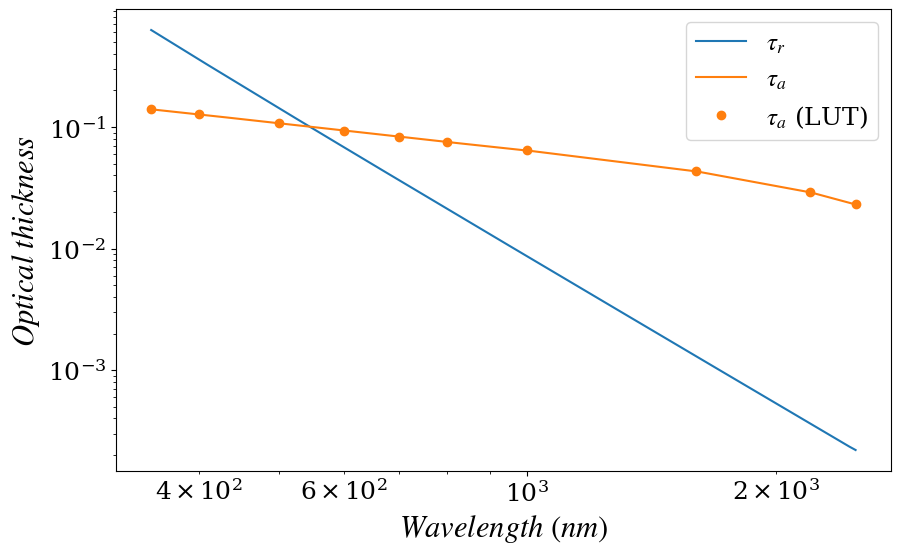

In [6]:
# Rayleigh optical thickness
tau_r = lut.rot * pressure / 1013.25

# aerosol optical thickness of the mixture, at the wavelengths of the LUT
tau_a_lut = lut.aot_lut.interp(aot_ref=aot550).squeeze(drop=True).reset_coords(drop=True)
# log-log interpolation at the wavelengths of the simulation
ln_tau = np.log(tau_a_lut).assign_coords(wl=np.log(tau_a_lut.wl.values))
tau_a = np.exp(ln_tau.interp(wl=np.log(full_wl.values))).assign_coords(wl=full_wl.values)

fig, ax = plt.subplots(figsize=(10, 6))
tau_r.plot(ax=ax, label=r'$\tau_r$')
tau_a.plot(ax=ax, label=r'$\tau_a$')
tau_a_lut.plot(ax=ax, ls='', marker='o', c='C1', label=r'$\tau_a$ (LUT)')
ax.loglog()
ax.set_xlabel(r'$Wavelength\ (nm)$')
ax.set_ylabel(r'$Optical\ thickness$')
ax.legend();

## Direct, total and diffuse irradiance

The total irradiance transmittance $T^{\downarrow}$ (`lut.trans_Ed`) is interpolated at the aerosol
optical thickness and at the wavelengths of the simulation.

In [7]:
# direct irradiance (Beer-Lambert)
T_dir = np.exp(-(tau_r + tau_a) / mu0)
E_dir = E0 * Tg * T_dir

# total irradiance (radiative transfer look-up table)
T_tot = (lut.trans_Ed.squeeze(drop=True).interp(aot_ref=aot550).interp(wl=full_wl, method='quadratic')
             .reset_coords(drop=True))
E_d = E0 * Tg * T_tot

# diffuse irradiance of the sky
E_diff = E_d - E_dir

irradiance = xr.Dataset({'E0': E0, 'Ed': E_d, 'Edir': E_dir, 'Ediff': E_diff})
irradiance.attrs['unit'] = 'mW m-2 nm-1'
irradiance

<xarray.Dataset> Size: 861kB
Dimensions:  (wl: 21532)
Coordinates:
  * wl       (wl) float64 172kB 350.1 350.3 350.5 ... 2.499e+03 2.5e+03
Data variables:
    E0       (wl) float64 172kB 871.1 823.8 1.037e+03 ... 37.75 37.87 37.88
    Ed       (wl) float64 172kB 604.6 572.2 721.0 ... 0.08868 0.04779 1.722
    Edir     (wl) float64 172kB 318.7 302.0 381.0 ... 0.08643 0.04657 1.679
    Ediff    (wl) float64 172kB 285.9 270.2 340.0 ... 0.002255 0.001214 0.04374
Attributes:
    unit:     mW m-2 nm-1

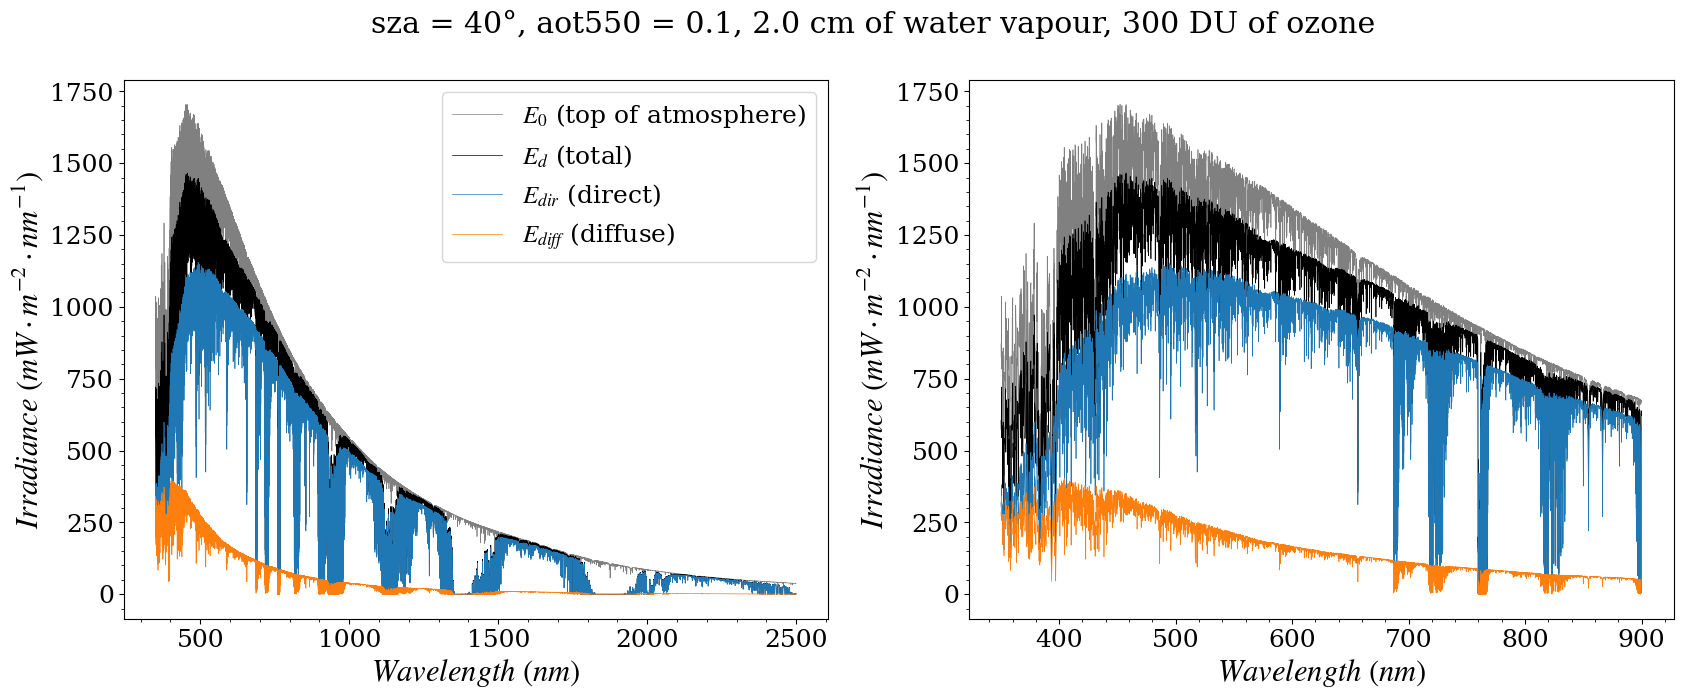

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
for ax, wl_range in zip(axs, [slice(350, 2500), slice(350, 900)]):
    irr = irradiance.sel(wl=wl_range)
    irr.E0.plot(ax=ax, lw=0.5, c='grey', label=r'$E_0$ (top of atmosphere)')
    irr.Ed.plot(ax=ax, lw=0.5, c='k', label=r'$E_d$ (total)')
    irr.Edir.plot(ax=ax, lw=0.5, c='C0', label=r'$E_{dir}$ (direct)')
    irr.Ediff.plot(ax=ax, lw=0.5, c='C1', label=r'$E_{diff}$ (diffuse)')
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel(r'$Irradiance\ (mW\cdot m^{-2}\cdot nm^{-1})$')
    ax.minorticks_on()
axs[0].legend()
fig.suptitle(f'sza = {sza:.0f}°, aot550 = {aot550}, {tpw_cm} cm of water vapour, {to3_du:.0f} DU of ozone');

The diffuse fraction $E_{diff}/E_d$ is large in the blue, where the Rayleigh scattering is strong,
and decreases with the wavelength:

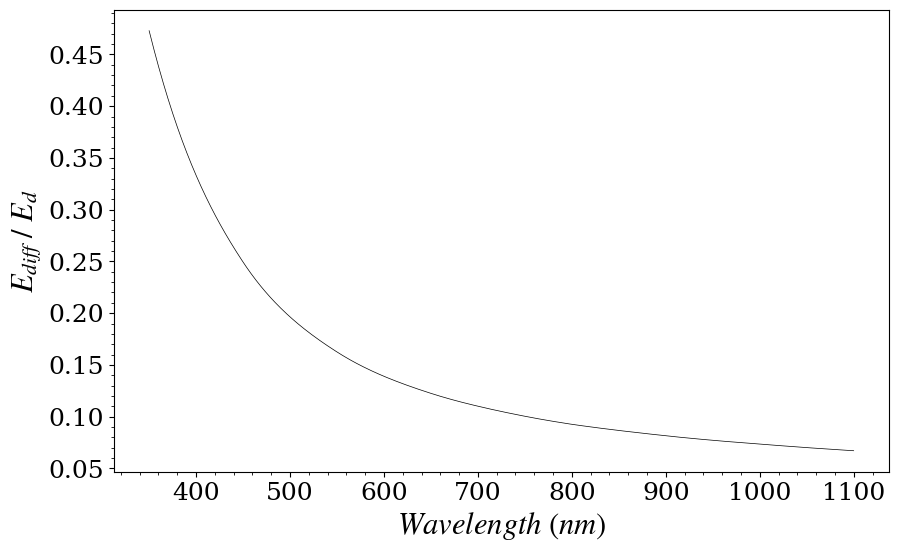

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
(irradiance.Ediff / irradiance.Ed).sel(wl=slice(350, 1100)).plot(ax=ax, lw=0.5, c='k')
ax.set_xlabel(r'$Wavelength\ (nm)$')
ax.set_ylabel(r'$E_{diff}\ /\ E_d$')
ax.minorticks_on()

## Sensitivity to the atmosphere

The computation is wrapped into a function of the aerosol optical thickness, the water vapour and the
ozone columns (same geometry, look-up tables already prepared for the solar zenith angle):

In [10]:
def downwelling_irradiance(aot550=0.1, tpw_cm=2.0, to3_du=300.):
    """Direct and total downwelling irradiance (mW m-2 nm-1) at the surface."""
    gas_trans.gas_tc['h2o'] = tpw_cm * 10
    gas_trans.gas_tc['o3'] = to3_du * 2.14485e-5
    Tg = gas_trans.get_gaseous_transmittance()

    tau_a_lut = lut.aot_lut.interp(aot_ref=aot550).squeeze(drop=True).reset_coords(drop=True)
    ln_tau = np.log(tau_a_lut).assign_coords(wl=np.log(tau_a_lut.wl.values))
    tau_a = np.exp(ln_tau.interp(wl=np.log(full_wl.values))).assign_coords(wl=full_wl.values)

    E_dir = E0 * Tg * np.exp(-(tau_r + tau_a) / mu0)
    T_tot = (lut.trans_Ed.squeeze(drop=True).interp(aot_ref=aot550).interp(wl=full_wl, method='quadratic')
             .reset_coords(drop=True))
    E_d = E0 * Tg * T_tot
    return E_dir, E_d

**Aerosols**: the direct irradiance decreases quickly with the aerosol optical thickness, while a
part of the scattered light still reaches the surface as diffuse irradiance, so the total irradiance
decreases more slowly.

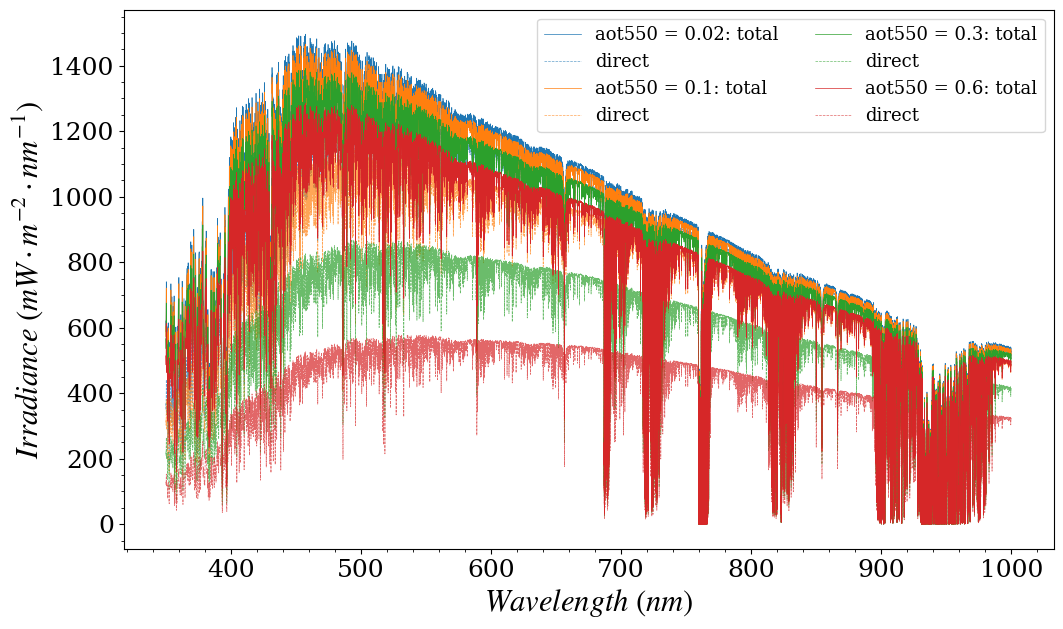

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
wl_range = slice(350, 1000)
for i, aot in enumerate([0.02, 0.1, 0.3, 0.6]):
    E_dir_, E_d_ = downwelling_irradiance(aot550=aot)
    E_d_.sel(wl=wl_range).plot(ax=ax, lw=0.5, c=f'C{i}', label=f'aot550 = {aot}: total')
    E_dir_.sel(wl=wl_range).plot(ax=ax, lw=0.5, c=f'C{i}', ls='--', alpha=0.7, label='direct')
ax.set_xlabel(r'$Wavelength\ (nm)$')
ax.set_ylabel(r'$Irradiance\ (mW\cdot m^{-2}\cdot nm^{-1})$')
ax.minorticks_on()
ax.legend(ncol=2, fontsize=13);

**Water vapour and ozone**: they only change the gaseous transmittance, in the water vapour
absorption bands (720, 820, 940, 1140 nm...) and in the Chappuis band of ozone (500--700 nm).

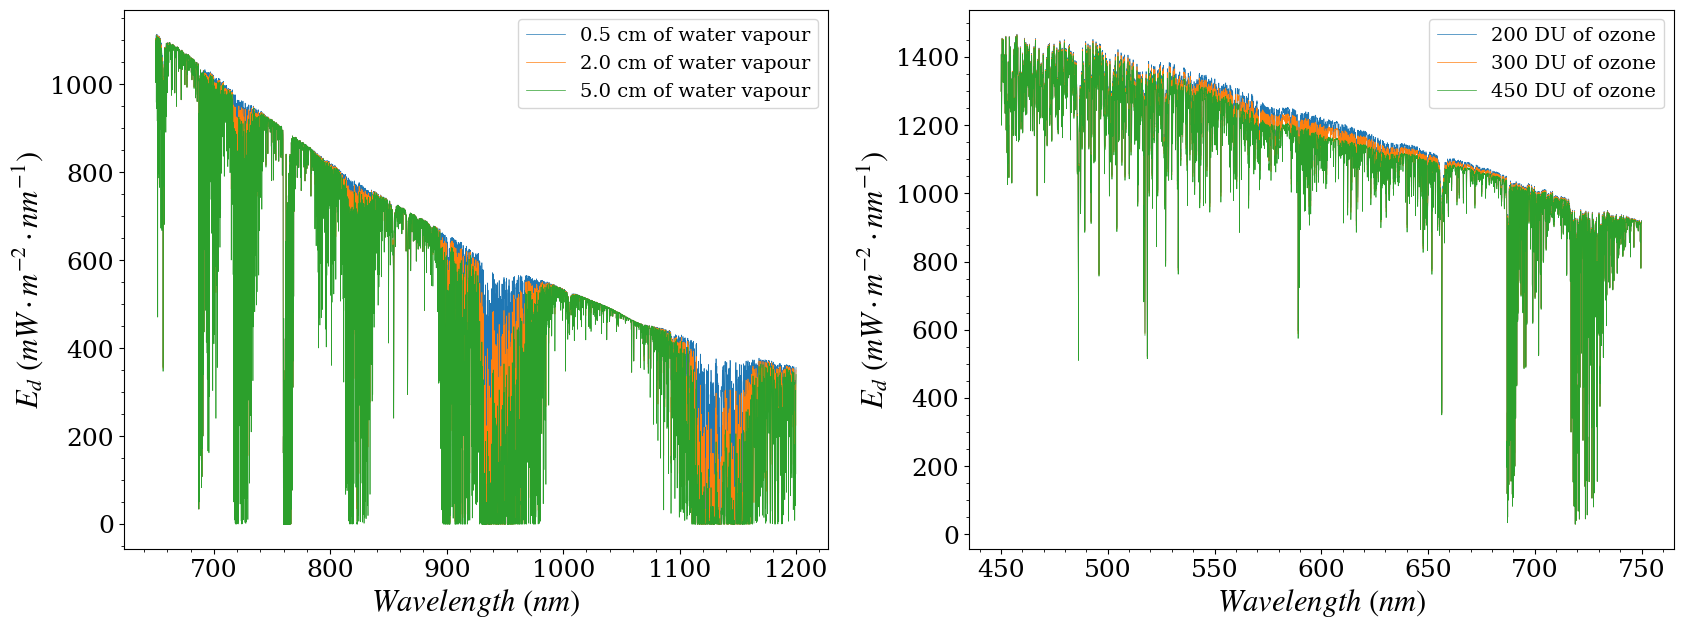

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(20, 7))
for i, tpw in enumerate([0.5, 2., 5.]):
    _, E_d_ = downwelling_irradiance(tpw_cm=tpw)
    E_d_.sel(wl=slice(650, 1200)).plot(ax=axs[0], lw=0.5, c=f'C{i}', label=f'{tpw} cm of water vapour')
for i, o3 in enumerate([200., 300., 450.]):
    _, E_d_ = downwelling_irradiance(to3_du=o3)
    E_d_.sel(wl=slice(450, 750)).plot(ax=axs[1], lw=0.5, c=f'C{i}', label=f'{o3:.0f} DU of ozone')
for ax in axs:
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel(r'$E_d\ (mW\cdot m^{-2}\cdot nm^{-1})$')
    ax.minorticks_on()
    ax.legend(fontsize=14);

## Photosynthetically available radiation

PAR of the total and direct irradiance (Eq. {eq}`par`,
{py:meth}`Radiometry.PAR <radcalnet_oc.kernel.Radiometry.PAR>`), in µmol photons m$^{-2}$ s$^{-1}$:

In [13]:
radiometry = radoc.Radiometry()
PAR_total = radiometry.PAR(irradiance.Ed)
PAR_direct = radiometry.PAR(irradiance.Edir)
print(f'PAR total : {PAR_total:.0f} µmol photons m-2 s-1')
print(f'PAR direct: {PAR_direct:.0f} µmol photons m-2 s-1 ({100 * PAR_direct / PAR_total:.0f} %)')

PAR total : 1589 µmol photons m-2 s-1
PAR direct: 1313 µmol photons m-2 s-1 (83 %)


## Values for the bands of a sensor

Band-averaged irradiance for bands of 20 nm full width at half maximum (super-Gaussian spectral
responses, {py:meth}`Spectral.convolve2 <radcalnet_oc.lut.Spectral.convolve2>`, Eq. {eq}`convolution`):

In [14]:
bands = np.array([443., 490., 560., 665., 705., 740., 783., 842., 865., 1610., 2190.])
spectral = radoc.Spectral(central_wl=bands, fwhm=20.)
irradiance_bands = xr.Dataset({name: spectral.convolve2(irradiance[name].rename(name))
                               for name in ['E0', 'Ed', 'Edir', 'Ediff']})
irradiance_bands.to_dataframe().round(1)

,E0,Ed,Edir,Ediff
wl,,,,
443.0,1403.800049,1190.099976,882.099976,307.899994
490.0,1471.699951,1294.300049,1028.699951,265.700012
560.0,1381.300049,1226.000000,1033.300049,192.699997
665.0,1134.699951,1057.699951,932.400024,125.199997
705.0,1043.699951,939.400024,837.000000,102.500000
740.0,956.200012,873.500000,784.299988,89.199997
783.0,871.400024,831.500000,752.500000,79.099998
842.0,752.000000,700.400024,639.099976,61.299999
865.0,703.299988,685.500000,627.200012,58.299999
